In [202]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import quad
import os

def lennard_jones(r, epsilon, sigma):
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def integrand(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj(T, epsilon, sigma, n):
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error

def lennard_jones_cut(r, epsilon, sigma):
    if r > sigma:
        return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)
    else:
        return np.inf

def integrand_cut(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones_cut(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj_cut(T, epsilon, sigma, n):
    # r_min = 0.001 * sigma
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand_cut, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error / 3

def vdw(T, epsilon, sigma, n):
    return n * T / (1 - 2 * n * np.pi * sigma ** 3 / 3) - 2 * np.pi * sigma**3 * 4 * epsilon * n**2 / 3

In [203]:
0.2**12-0.2**6

-6.399590400000002e-05

In [204]:
def rho(n, r):
    return 4 * n * np.pi * r**3 / 3

pressures = []
rs = []
energies = []
# eps = [0, 0.1, 0.25, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
# eps = [0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.25, 0.3, 0.5, 1, 1.5, 2, 0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.25, 0.3, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
dirs = []
epsilons = []
steps = []
p_lj_cuts = []
p_ljs = []
timeLines = []
T_STOP = 50.0

i = 0
for d in os.listdir('.'):
    if os.path.isdir(d) and '20250906_224200' <= d[:15] <= '20250907_010000':
        dirs.append(d)
        r = float(d.split('r')[-1])
        rs.append(r)
        fs = os.listdir(os.path.join('.', d))
        assert "mean_v2.npy" in fs and "pressure.npy" in fs, f"Missing files in {d}"
        pressures.append(np.load(os.path.join('.', d, "pressure.npy")))
        energies.append(np.load(os.path.join('.', d, "mean_v2.npy")) * 200 / 3)
        # epsilons.append(np.load(os.path.join('.', d, "l_j_epsilon.npy")))
        # assert np.abs(epsilons[-1].mean() - eps[i]) < 1e-5, f"Expected epsilon {eps[i]} in {d}, found {epsilons[-1].mean()}"
        # steps.append(np.load(os.path.join('.', d, "steps.npy")))
        p_lj_cuts.append(np.array([pressure_lj_cut(T, 0, r, 32) for T in energies[i]]))
        p_ljs.append(np.array([pressure_lj(T, 0, r, 32) for T in energies[i]]))
        timeLines.append(np.linspace(0, T_STOP, len(energies[-1])))
        i += 1
# assert i == len(eps), f"Expected {len(eps)} directories, found {i}"
p_per_Ts = [((pressures[i][1:]+pressures[i][:-1]) / energies[i][:-1] / 2) for i in range(len(dirs))]

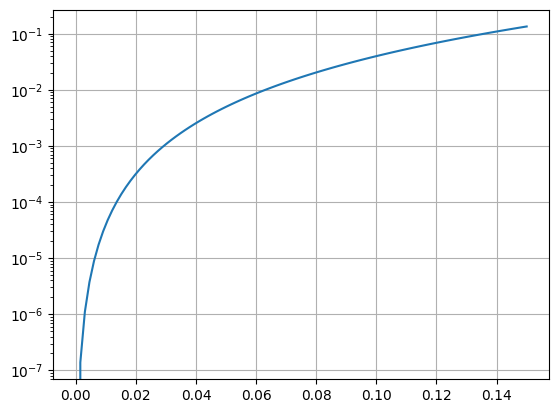

In [205]:
plt.plot(np.linspace(0, 0.15, 100), rho(32,np.linspace(0, 0.1, 100)))
plt.yscale('log')
plt.grid()

In [206]:
0.5**12-0.5**6

-0.015380859375

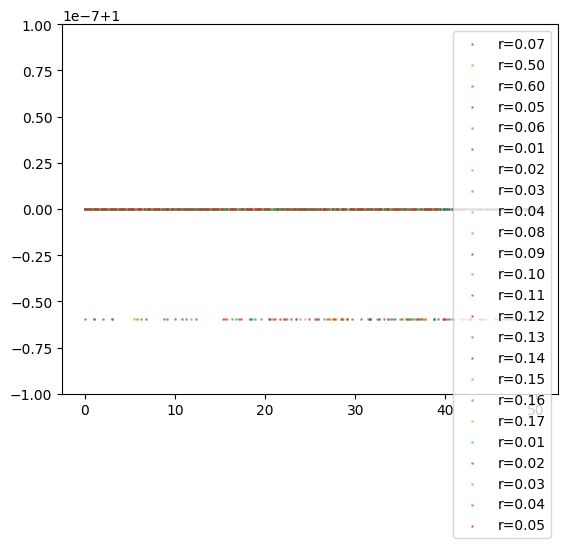

In [207]:
for i in range(len(dirs)):
    plt.scatter(timeLines[i], energies[i], label=f"r={rs[i]:.2f}", s=1, alpha=0.5)
plt.legend()
plt.ylim(0.9999999, 1.0000001)
plt.show()

C:\Users\hy-wu.DESKTOP-G355NC5\AppData\Local\Temp\ipykernel_5336\1784300201.py:36: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  integral, error = quad(integrand_cut, r_min, r_max, args=(T, epsilon, sigma))


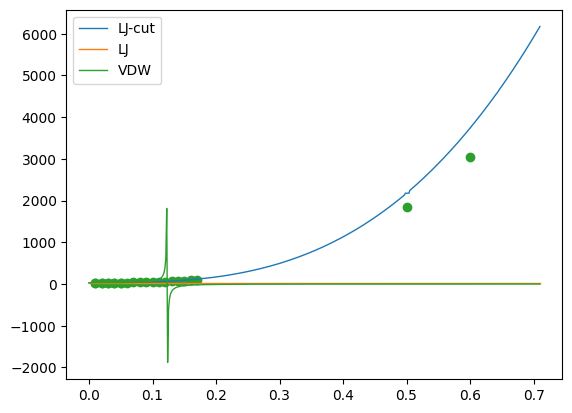

In [208]:
rss = np.linspace(0, 0.71, 500)
cms = []
ces = []
for r in rss:
    m, e = pressure_lj_cut(1.0, 0, r * 2, 32)
    cms.append(m / 1.0)
    ces.append(e * m)
cms = np.array(cms)
ces = np.array(ces)
plt.plot(rss, cms, label="LJ-cut", linewidth=1)
plt.fill_between(rss, cms-ces, cms+ces, alpha=0.5)
lms = []
les = []
for r in rss:
    m, e = pressure_lj(1.0, 0, r * 2, 32)
    lms.append(m / 1.0)
    les.append(e * m)
lms = np.array(lms)
les = np.array(les)
plt.plot(rss, lms, label="LJ", linewidth=1)
plt.fill_between(rss, lms-les, lms+les, alpha=0.5)
plt.plot(rss, [vdw(1.0, 0, r * 2, 32) / 1.0 for r in rss], label="VDW", linewidth=1)
plt.scatter(rs, [p_per_Ts[i][-25:].mean() for i in range(len(dirs))])
plt.legend()
# plt.yscale('log')
# plt.xlim(0, 0.11)
# plt.ylim(30, 50)

In [209]:
[p[-int(len(p) * 0.5):].mean() for p in pressures]

[38.799703478518154,
 2145.479348269585,
 5443.243107755526,
 35.194303996913774,
 36.76364382618785,
 32.07750625219179,
 32.265654094606305,
 32.64241885366566,
 33.80712078910543,
 41.66785527903,
 44.62188478063012,
 48.79397883026686,
 53.782458856688805,
 58.923286850869154,
 65.94948354180727,
 73.50095028063451,
 82.74963181242926,
 93.67494631321047,
 105.85711838729738,
 31.92846019666784,
 32.259803706043186,
 32.791261987404965,
 33.749364179640686,
 34.98641712421827]

(30.0, 50.0)

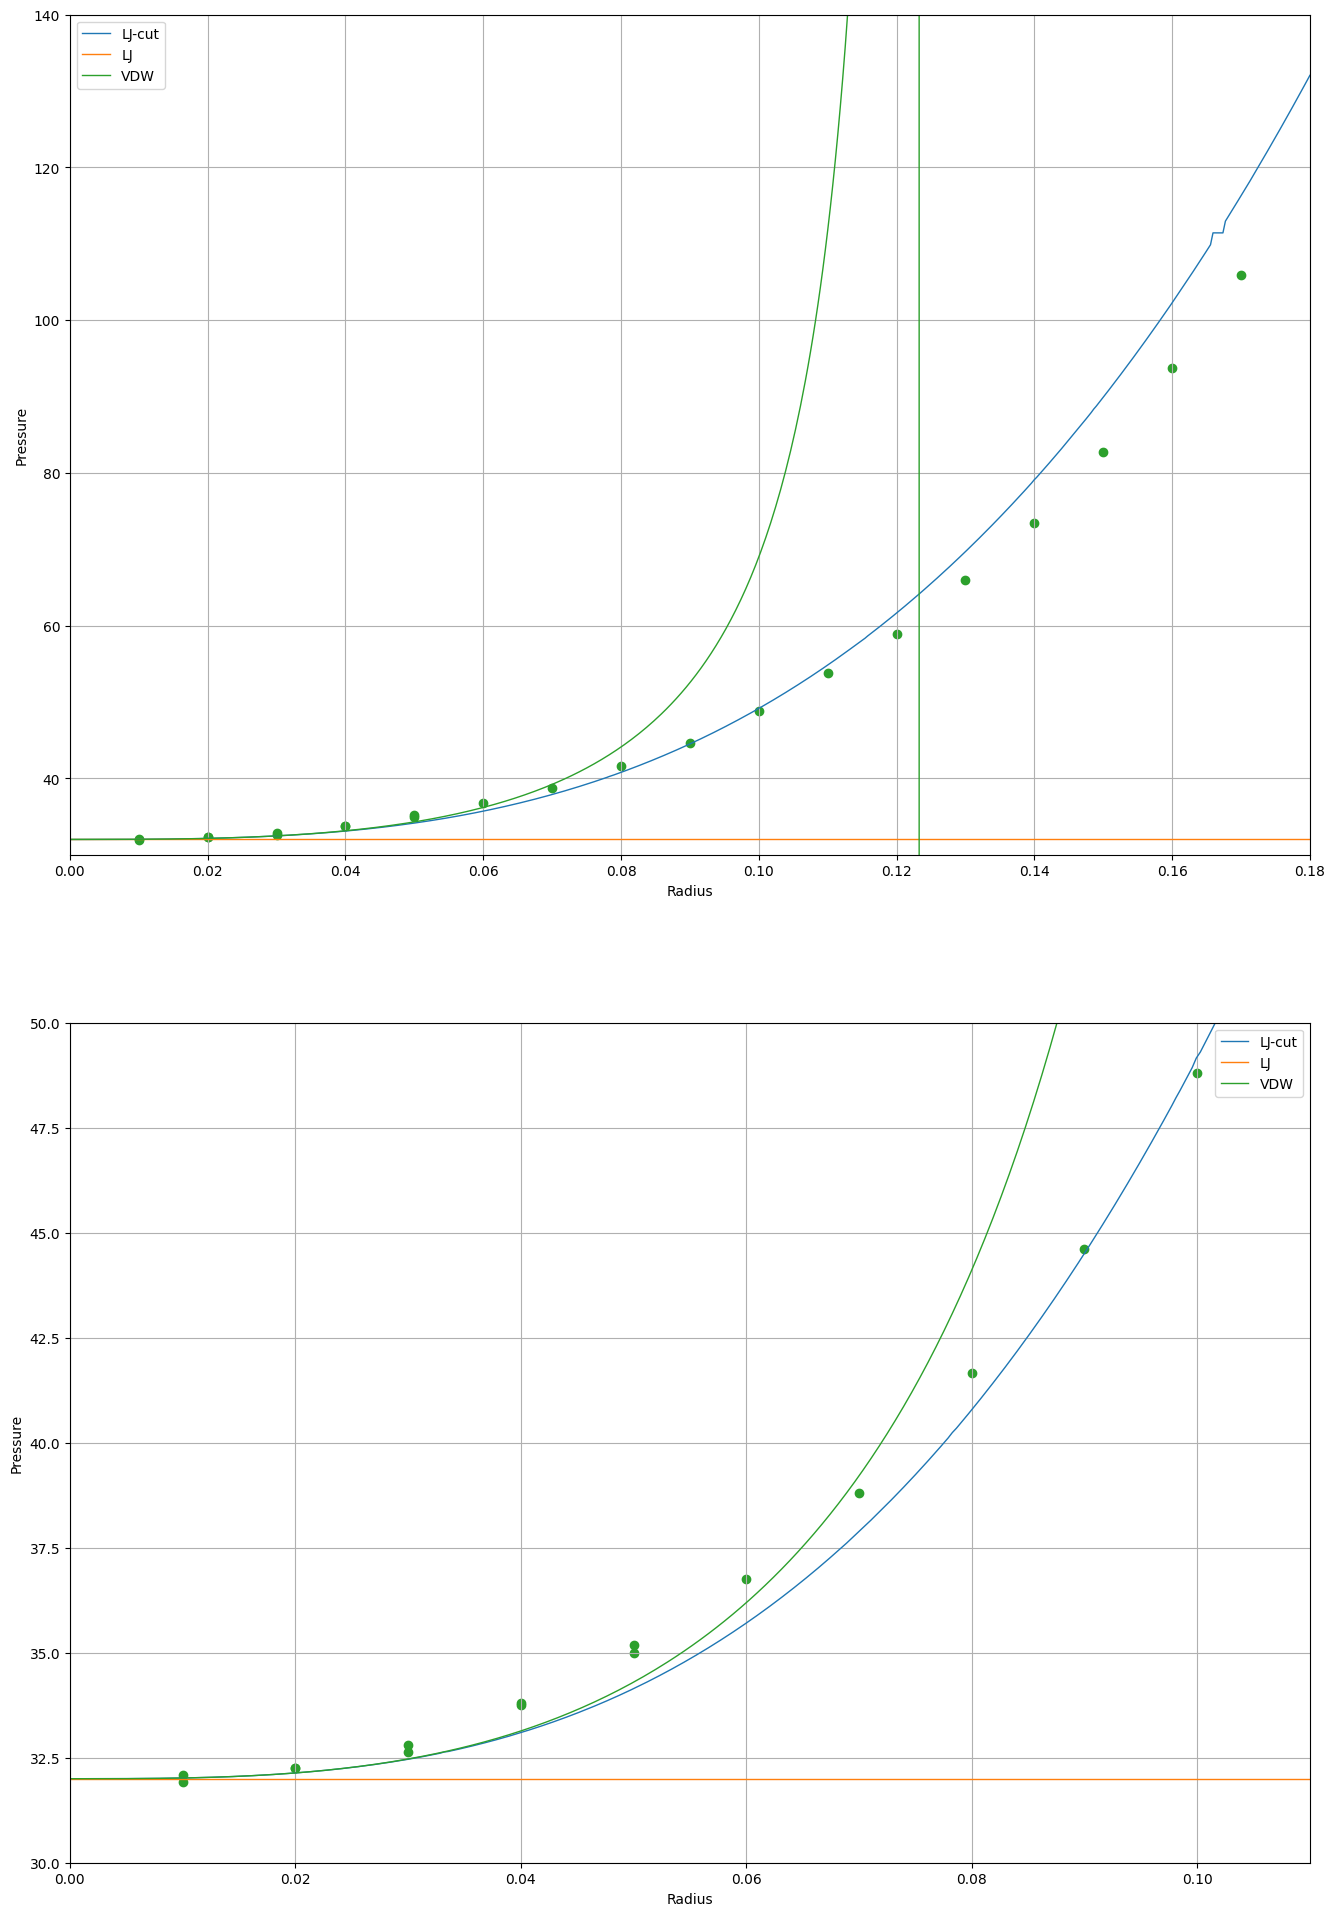

In [210]:
rss = np.linspace(0, 0.18, 500)
cms = []
ces = []
for r in rss:
    m, e = pressure_lj_cut(1.0, 0, r * 2, 32)
    cms.append(m)
    ces.append(e * m)
cms = np.array(cms)
ces = np.array(ces)
lms = []
les = []
for r in rss:
    m, e = pressure_lj(1.0, 0, r * 2, 32)
    lms.append(m)
    les.append(e * m)
lms = np.array(lms)
les = np.array(les)
figs, axs = plt.subplots(2, 1, figsize=(16, 24))
for ax in axs:
    ax.plot(rss, cms, label="LJ-cut", linewidth=1)
    ax.fill_between(rss, cms-ces, cms+ces, alpha=0.5)
    ax.plot(rss, lms, label="LJ", linewidth=1)
    ax.fill_between(rss, lms-les, lms+les, alpha=0.5)
    ax.plot(rss, [vdw(1.0, 0, r * 2, 32) for r in rss], label="VDW", linewidth=1)
    # ax.scatter(rs, [p[-25:].mean() for p in pressures])
    ax.scatter(rs, [p[-int(len(p) * 0.5):].mean() for p in pressures])
    ax.legend()
    ax.grid()
    ax.set_xlabel("Radius")
    ax.set_ylabel("Pressure")
# plt.yscale('log')
axs[0].set_xlim(0, 0.18)
axs[0].set_ylim(30, 140)
axs[1].set_xlim(0, 0.11)
axs[1].set_ylim(30, 50)